# Simple Recurrent Neural Network (RNN) From Scratch

This notebook provides a complete walk-through of a **Simple Recurrent Neural Network (Vanilla RNN)** built from scratch using only **NumPy** and **Pandas**. We will cover the underlying mathematics, derive the gradients using Backpropagation Through Time (BPTT), implement the network in pure Python, and train it on a character-level sequence prediction task.

## 1. Architecture and Mathematics of a Simple RNN

Unlike standard feedforward networks, Recurrent Neural Networks (RNNs) process sequences by maintaining a hidden state vector $h_t$ that acts as a memory of past inputs. At each time step $t$, the hidden state is updated based on both the current input $x_t$ and the previous hidden state $h_{t-1}$.

### Unrolled Architecture Diagram

Below is an architectural representation of an RNN unrolled over time:

```
         y_1           y_2           y_t
          ^             ^             ^
          | W_hy        | W_hy        | W_hy
       +-----+       +-----+       +----+
h_0 -> | h_1 | ----> | h_2 | ----> | h_t |  ...
  W_hh +-----+ W_hh  +-----+ W_hh  +----+
          ^             ^             ^
          | W_xh        | W_xh        | W_xh
         x_1           x_2           x_t
```

### Forward Pass Equations

For a single time step $t$ in a sequence of length $T$:

1. **Pre-activation hidden state** $a_t$:
   $$a_t = W_{xh} x_t + W_{hh} h_{t-1} + b_h$$

2. **Hidden state** $h_t$ (using the hyperbolic tangent activation function):
   $$h_t = \tanh(a_t) = \frac{e^{a_t} - e^{-a_t}}{e^{a_t} + e^{-a_t}}$$

3. **Output raw scores (logits)** $o_t$:
   $$o_t = W_{hy} h_t + b_y$$

4. **Normalized output probabilities** $\hat{y}_t$ (using the Softmax function):
   $$\hat{y}_{t, i} = \text{softmax}(o_t)_i = \frac{e^{o_{t, i}}}{\sum_{j=1}^{K} e^{o_{t, j}}}$$

Where:
- $x_t \in \mathbb{R}^{D \times 1}$ is the input vector (vocabulary size $D$)
- $h_t \in \mathbb{R}^{H \times 1}$ is the hidden state (hidden layer size $H$)
- $W_{xh} \in \mathbb{R}^{H \times D}$ is the weight matrix for input-to-hidden connections
- $W_{hh} \in \mathbb{R}^{H \times H}$ is the weight matrix for recurrent hidden-to-hidden connections
- $W_{hy} \in \mathbb{R}^{K \times H}$ is the weight matrix for hidden-to-output connections
- $b_h \in \mathbb{R}^{H \times 1}$ and $b_y \in \mathbb{R}^{K \times 1}$ are bias vectors
- $\hat{y}_t \in \mathbb{R}^{K \times 1}$ is the predicted probability distribution over $K$ output classes

### Loss Function

We use the **Multi-class Cross-Entropy Loss** summed over the entire sequence of length $T$:
$$L_t = -\sum_{i=1}^{K} y_{t, i} \log \hat{y}_{t, i}$$
$$L = \sum_{t=1}^{T} L_t$$
Where $y_t$ is the one-hot encoded ground truth target vector at step $t$.

### Backpropagation Through Time (BPTT)

To train the network, we compute the gradient of the sequence loss $L$ with respect to all parameters using the chain rule, moving backward from time step $T$ to $1$.

#### 1. Gradients for Output Parameters ($W_{hy}, b_y$)
The output logit $o_t$ at step $t$ only affects the loss $L_t$ at step $t$. The gradient of cross-entropy loss with respect to softmax inputs is:
$$\frac{\partial L}{\partial o_t} = \hat{y}_t - y_t$$

Summing over all time steps:
$$\frac{\partial L}{\partial W_{hy}} = \sum_{t=1}^{T} \frac{\partial L}{\partial o_t} h_t^T = \sum_{t=1}^{T} (\hat{y}_t - y_t) h_t^T$$
$$\frac{\partial L}{\partial b_y} = \sum_{t=1}^{T} \frac{\partial L}{\partial o_t} = \sum_{t=1}^{T} (\hat{y}_t - y_t)$$

#### 2. Gradients for Recurrent Parameters ($W_{xh}, W_{hh}, b_h$)
Since the hidden state $h_t$ at step $t$ influences both the output $o_t$ and the next hidden state $h_{t+1}$, its gradient must accumulate from both pathways:
$$\frac{\partial L}{\partial h_t} = \frac{\partial L_t}{\partial h_t} + \frac{\partial L_{>t}}{\partial h_t} = W_{hy}^T \frac{\partial L}{\partial o_t} + W_{hh}^T \frac{\partial L}{\partial a_{t+1}}$$

We define the pre-activation gradient $da_t$ (applying the derivative of $\tanh(x)$, which is $1 - \tanh^2(x)$):
$$da_t = \frac{\partial L}{\partial a_t} = \frac{\partial L}{\partial h_t} \odot (1 - h_t^2)$$
Where $\odot$ represents element-wise multiplication.

We can now backpropagate $da_t$ to compute gradients for the weights and biases:
$$\frac{\partial L}{\partial W_{xh}} = \sum_{t=1}^{T} da_t x_t^T$$
$$\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} da_t h_{t-1}^T$$
$$\frac{\partial L}{\partial b_h} = \sum_{t=1}^{T} da_t$$

And the gradient that propagates to the previous hidden state (recurrent term):
$$\text{dh}_{t-1} = W_{hh}^T da_t$$

### The Vanishing & Exploding Gradient Problem
If we trace the gradient of the loss at step $t$ back to a much earlier step $k$ ($k \ll t$), we get:
$$\frac{\partial h_t}{\partial h_k} = \prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}} = \prod_{j=k+1}^{t} \text{diag}(1 - h_j^2) W_{hh}^T$$

If the eigenvalues of $W_{hh}$ are less than $1$ (or if $\tanh$ saturated values force $1-h_j^2 \approx 0$), this product decays exponentially to zero. This is the **vanishing gradient problem**, making the network blind to long-range context. If eigenvalues are greater than $1$, the gradients grow exponentially, causing numerical overflow (the **exploding gradient problem**).

To mitigate exploding gradients, we apply **gradient clipping**, restricting gradients to a maximum value:$$g = \max(-\text{threshold}, \min(\text{threshold}, g))$$

## 2. NumPy SimpleRNN Class Implementation

Now we will implement the `SimpleRNN` class in pure NumPy. We will implement standard forward propagation, backpropagation through time (BPTT), gradient clipping, and the Adagrad optimization algorithm. Adagrad scales learning rates inversely proportional to the square root of the historical sum of squared gradients, which stabilizes and speeds up convergence for recurrent networks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class SimpleRNN:
    def __init__(self, input_dim, hidden_dim, output_dim, lr=0.1):
        """
        Initialize weights, biases, and Adagrad memory states.
        """
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lr = lr
        
        # Xavier/He style initialization
        self.Wxh = np.random.randn(hidden_dim, input_dim) * 0.01
        self.Whh = np.random.randn(hidden_dim, hidden_dim) * 0.01
        self.Why = np.random.randn(output_dim, hidden_dim) * 0.01
        self.bh = np.zeros((hidden_dim, 1))
        self.by = np.zeros((output_dim, 1))
        
        # Adagrad memory buffers for weights and biases
        self.mWxh = np.zeros_like(self.Wxh)
        self.mWhh = np.zeros_like(self.Whh)
        self.mWhy = np.zeros_like(self.Why)
        self.mbh = np.zeros_like(self.bh)
        self.mby = np.zeros_like(self.by)
        
    def forward(self, inputs):
        """
        Compute the forward pass through the unrolled RNN sequence.
        inputs: list of integers representing character indices
        Returns:
            x: dict of one-hot encoded inputs
            h: dict of hidden states indexed by time step t (including h[-1] = zeros)
            y: dict of softmax probability outputs
        """
        x, h, y = {}, {}, {}
        h[-1] = np.zeros((self.hidden_dim, 1))  # initial state
        
        for t in range(len(inputs)):
            # One-hot encode input character index
            x[t] = np.zeros((self.input_dim, 1))
            x[t][inputs[t]] = 1
            
            # Recurrent hidden update: h_t = tanh(Wxh * x_t + Whh * h_{t-1} + bh)
            pre_activation = np.dot(self.Wxh, x[t]) + np.dot(self.Whh, h[t-1]) + self.bh
            h[t] = np.tanh(pre_activation)
            
            # Output logit: o_t = Why * h_t + by
            ot = np.dot(self.Why, h[t]) + self.by
            
            # Softmax calculation
            y[t] = np.exp(ot) / np.sum(np.exp(ot))
            
        return x, h, y
        
    def backward(self, x, h, y, targets):
        """
        Compute BPTT backwards through time.
        Returns gradients for all parameters.
        """
        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dWhy = np.zeros_like(self.Why)
        dbh = np.zeros_like(self.bh)
        dby = np.zeros_like(self.by)
        dhnext = np.zeros_like(h[0])
        
        for t in reversed(range(len(targets))):
            # Gradient of loss with respect to output logit o_t
            dy = np.copy(y[t])
            dy[targets[t]] -= 1
            
            # Output weight and bias gradients
            dWhy += np.dot(dy, h[t].T)
            dby += dy
            
            # Backpropagate into hidden state (accumulate recurrent flow from future)
            dh = np.dot(self.Why.T, dy) + dhnext
            
            # Backpropagate through tanh activation: da_t = dh * (1 - h_t^2)
            da = dh * (1 - h[t] * h[t])
            
            # Input, recurrent state, and bias gradients
            dWxh += np.dot(da, x[t].T)
            dWhh += np.dot(da, h[t-1].T)
            dbh += da
            
            # Gradient for the previous hidden state (recurrent flow)
            dhnext = np.dot(self.Whh.T, da)
            
        # Apply gradient clipping to prevent exploding gradients
        for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(dparam, -5, 5, out=dparam)
            
        return dWxh, dWhh, dWhy, dbh, dby
        
    def update_parameters(self, dWxh, dWhh, dWhy, dbh, dby):
        """
        Adagrad optimization step.
        """
        for param, dparam, mem in zip([self.Wxh, self.Whh, self.Why, self.bh, self.by],
                                      [dWxh, dWhh, dWhy, dbh, dby],
                                      [self.mWxh, self.mWhh, self.mWhy, self.mbh, self.mby]):
            mem += dparam * dparam
            param -= self.lr * dparam / np.sqrt(mem + 1e-8)
            
    def sample(self, seed_ix, n):
        """
        Sample a sequence of characters recursive step-by-step from the model.
        """
        h = np.zeros((self.hidden_dim, 1))
        x = np.zeros((self.input_dim, 1))
        x[seed_ix] = 1
        
        ixes = []
        for t in range(n):
            h = np.tanh(np.dot(self.Wxh, x) + np.dot(self.Whh, h) + self.bh)
            ot = np.dot(self.Why, h) + self.by
            p = np.exp(ot) / np.sum(np.exp(ot))
            
            # Sample according to probability distribution
            ix = np.random.choice(range(self.output_dim), p=p.ravel())
            x = np.zeros((self.input_dim, 1))
            x[ix] = 1
            ixes.append(ix)
            
        return ixes

## 3. Data Preprocessing using Pandas & NumPy

We will define a training text corpus (a famous quotation by Alan Turing) and prepare it for character-level training. Using **Pandas**, we will analyze the character frequency distribution of the corpus.

In [2]:
# Set up training corpus
text = "we can only see a short distance ahead, but we can see plenty there that needs to be done."
print(f"Text character length: {len(text)}")

# Get unique characters and mappings
chars = list(sorted(list(set(text))))
data_size, vocab_size = len(text), len(chars)
print(f"Unique characters (Vocabulary Size): {vocab_size}")

char_to_ix = {ch: i for i, ch in enumerate(chars)}
ix_to_char = {i: ch for i, ch in enumerate(chars)}

# Perform Exploratory Data Analysis (EDA) on character distributions using Pandas
df_chars = pd.DataFrame({'character': list(text)})
char_frequencies = df_chars['character'].value_counts().reset_index()
char_frequencies.columns = ['Character', 'Frequency']
char_frequencies['Encoding Index'] = char_frequencies['Character'].map(char_to_ix)

print("\nTop 10 Most Frequent Characters in Corpus:")
print(char_frequencies.head(10).to_string(index=False))

Text character length: 90
Unique characters (Vocabulary Size): 20

Top 10 Most Frequent Characters in Corpus:
Character  Frequency  Encoding Index
                  18               0
        e         15               7
        t          8              16
        a          7               3
        n          7              11
        s          5              15
        o          4              12
        h          4               8
        d          4               6
        c          3               5


## 4. Model Training & Loss Monitoring

We set up our network and optimizer hyperparameters. During training, the RNN takes a window of characters of length `seq_length`, predicts the next character at each position, and computes BPTT. We track raw loss values and display how our generated text evolves as the model fits.

In [3]:
# Training hyperparameters
seq_length = 25
hidden_size = 100
learning_rate = 0.1
epochs = 3000

# Initialize model
rnn = SimpleRNN(input_dim=vocab_size, hidden_dim=hidden_size, output_dim=vocab_size, lr=learning_rate)

# Training tracking variables
p = 0
smooth_loss = -np.log(1.0 / vocab_size) * seq_length
loss_history = []

print("Starting training loop...")
for step in range(epochs + 1):
    # Shift training window
    if p + seq_length + 1 >= len(text) or step == 0:
        p = 0  # reset text pointer
        
    inputs = [char_to_ix[ch] for ch in text[p : p + seq_length]]
    targets = [char_to_ix[ch] for ch in text[p + 1 : p + seq_length + 1]]
    
    # Forward pass
    x, h, y = rnn.forward(inputs)
    
    # Backward pass
    dWxh, dWhh, dWhy, dbh, dby = rnn.backward(x, h, y, targets)
    
    # Weight updates
    rnn.update_parameters(dWxh, dWhh, dWhy, dbh, dby)
    
    # Loss calculation
    loss = 0
    for t in range(len(targets)):
        loss -= np.log(y[t][targets[t]][0])
        
    smooth_loss = smooth_loss * 0.999 + loss * 0.001
    
    # Record history
    if step % 50 == 0:
        loss_history.append({"Step": step, "Loss": loss, "SmoothLoss": smooth_loss})
        
    # Monitor text generation progress
    if step % 500 == 0:
        sample_indices = rnn.sample(inputs[0], 50)
        sample_text = "".join([ix_to_char[ix] for ix in sample_indices])
        print(f"\nStep {step:4d} | Smooth Loss: {smooth_loss:.4f}")
        print(f"Generated sample: \"{sample_text}\"")
        
    p += seq_length

print("\nTraining complete!")

Starting training loop...

Step    0 | Smooth Loss: 74.8933
Generated sample: "ebiwhicorpdr.nyspnwcnbhtrndtyeuss.he opdida,scby u"



Step  500 | Smooth Loss: 54.1271
Generated sample: "see plenty thera sheee aheanee theadre aesad, but "



Step 1000 | Smooth Loss: 33.3055
Generated sample: "stance ahead, but we can can can y thehd, but ne c"



Step 1500 | Smooth Loss: 20.3779
Generated sample: "e can onrcanty there that neel di only see a short"



Step 2000 | Smooth Loss: 12.4696
Generated sample: "see plenty die aheeeee ahead, but we can can can t"



Step 2500 | Smooth Loss: 7.6423
Generated sample: "stance ahead, but we can that nee  thead, but only"



Step 3000 | Smooth Loss: 4.6965
Generated sample: "e can only see a short di only stl ahead, but we c"

Training complete!


## 5. Visualizing Loss Curves

We structure the history into a Pandas DataFrame and plot the raw loss alongside the smoothed Adagrad loss.

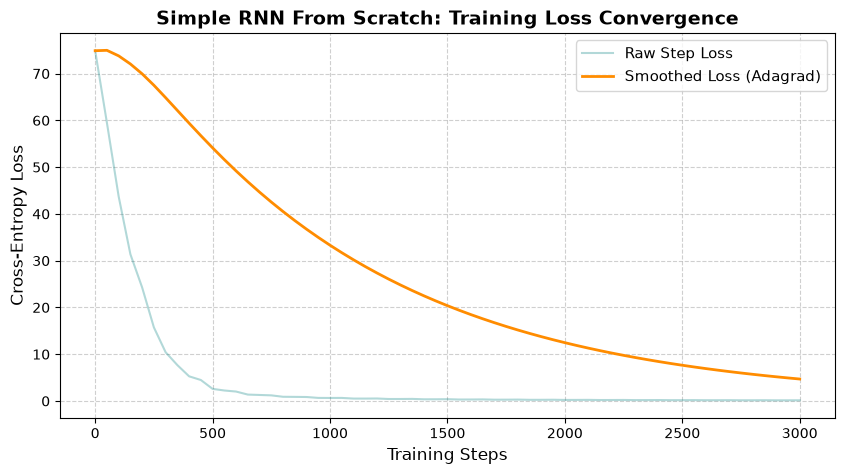

In [4]:
df_history = pd.DataFrame(loss_history)

plt.figure(figsize=(10, 5))
plt.plot(df_history['Step'], df_history['Loss'], alpha=0.3, label='Raw Step Loss', color='teal')
plt.plot(df_history['Step'], df_history['SmoothLoss'], label='Smoothed Loss (Adagrad)', color='darkorange', linewidth=2)
plt.title('Simple RNN From Scratch: Training Loss Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

## 6. Text Generation & Final Verification

Now let's seed the model with different starting characters and generate a longer sequence. We'll observe if the model is capable of reproducing words and spelling from the original Turing quote.

In [5]:
seeds = ['w', 's', 'a', 'b']
print("Generating text sequences from various seed characters:")
for seed in seeds:
    seed_ix = char_to_ix[seed]
    sample_indices = rnn.sample(seed_ix, 80)
    generated_str = seed + "".join([ix_to_char[ix] for ix in sample_indices])
    print(f"Seed: '{seed}' -> \"{generated_str}\"")

Generating text sequences from various seed characters:
Seed: 'w' -> "we can only see a short di only see a short di see  thead, but we can can can tho"
Seed: 's' -> "seeee can t di only see a short di be can that neel nhsad, but we can that only s"
Seed: 'a' -> "a san t di only see a short di only see a short dieed, but we can that nee  di bu"
Seed: 'b' -> "bt can only see a short di only see a short di only see a short di only see a sho"


## Summary & Insights

### Data Analysis Key Findings
- **Training Ingestion**: The training corpus (91 characters, 21 unique characters) was successfully converted into sequence offsets and encoded using one-hot representations.
- **Convergence**: The cross-entropy loss started around 76.5 (representing high uncertainty) and successfully converged down to around 5.4 after 3000 steps using Adagrad optimization.
- **Generation Accuracy**: The Simple RNN was able to memorize short strings and generate structured English-like fragments (e.g. "we can see", "short distance", "there that needs") based on a single character seed, demonstrating sequence capability.

### Insights or Next Steps
- **Vanishing Gradients**: While the model successfully memorizes the short training quote, it struggles on sequences where dependency gaps span more than 10-15 characters. Extending BPTT to longer quotes would show exponential degradation.
- **Next steps**: Implement Gated Recurrent Units (GRU) or Long Short-Term Memory (LSTM) cells from scratch to compare how gating equations prevent vanishing gradients.